In [1]:
!pip install numpy pandas matplotlib scipy scikit-learn --quiet

# Финальный проект Прогноз зашумлённого сигнала. Азимов Зейнал ПМИ-3 2026

## Постановка задачи

Имеются измерения вида:

    z(ti) = u(ti) + v(ti)

где `u(ti)` — полезный сигнал (модель неизвестна), `v(ti)` — белошумная центрированная ошибка измерения, `ti` — момент времени. Шаг дискретизации `Δt = 0.05 с`.

Требуется построить алгоритм прогноза полезного сигнала на **50 с вперёд** по **N = 4000 (200 с)** предшествующих измерений.

Критерии оценки:
1. Средняя ошибка прогноза `delta(ti)` по 500 тестовым реализациям.
2. Среднеквадратическая погрешность (СКП) `sigma(ti)` по 500 тестовым реализациям.

# _____________________________________________________________________

Обучающая выборка: 1000 реализаций x 5000 отсчётов. Тестовая выборка: 500 реализаций x 5000 отсчётов. Каждая реализация: 200 с наблюдений + 50 с горизонта прогноза.

### Подключение библиотек

In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [14, 5]
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

# параметры задачи
DT     = 0.05    # шаг дискретизации, с
N_OBS  = 4000    # длина окна наблюдения (200 с)
N_PRED = 1000    # горизонт прогноза (50 с)
N_TOTAL = 5000   # всего отсчётов в реализации
L      = 500     # число тестовых реализаций

t_obs  = np.arange(N_OBS)  * DT
t_pred = np.arange(N_PRED) * DT
t_full = np.arange(N_TOTAL) * DT

### Загрузка данных

In [3]:
train         = pd.read_csv('train.csv',           header=None).values
test          = pd.read_csv('test.csv',            header=None).values
etalon_train  = pd.read_csv('etalon_for_train.csv', header=None).values
etalon_test   = pd.read_csv('etalon_for_test.csv',  header=None).values

print(f'train:         {train.shape}')
print(f'test:          {test.shape}')
print(f'etalon_train:  {etalon_train.shape}')
print(f'etalon_test:   {etalon_test.shape}')

assert train.shape        == (1000, 5000), 'Неожиданный размер train'
assert test.shape         == (500,  5000), 'Неожиданный размер test'
assert etalon_train.shape == (1000, 5000), 'Неожиданный размер etalon_train'
assert etalon_test.shape  == (500,  5000), 'Неожиданный размер etalon_test'
print('Размерности корректны.')

train:         (1000, 5000)
test:          (500, 5000)
etalon_train:  (1000, 5000)
etalon_test:   (500, 5000)
Размерности корректны.


Все четыре матрицы загружены без ошибок. Размерности соответствуют условию задачи: 1000 обучающих и 500 тестовых реализаций по 5000 отсчётов (250 с).

### Исследовательский анализ (EDA)

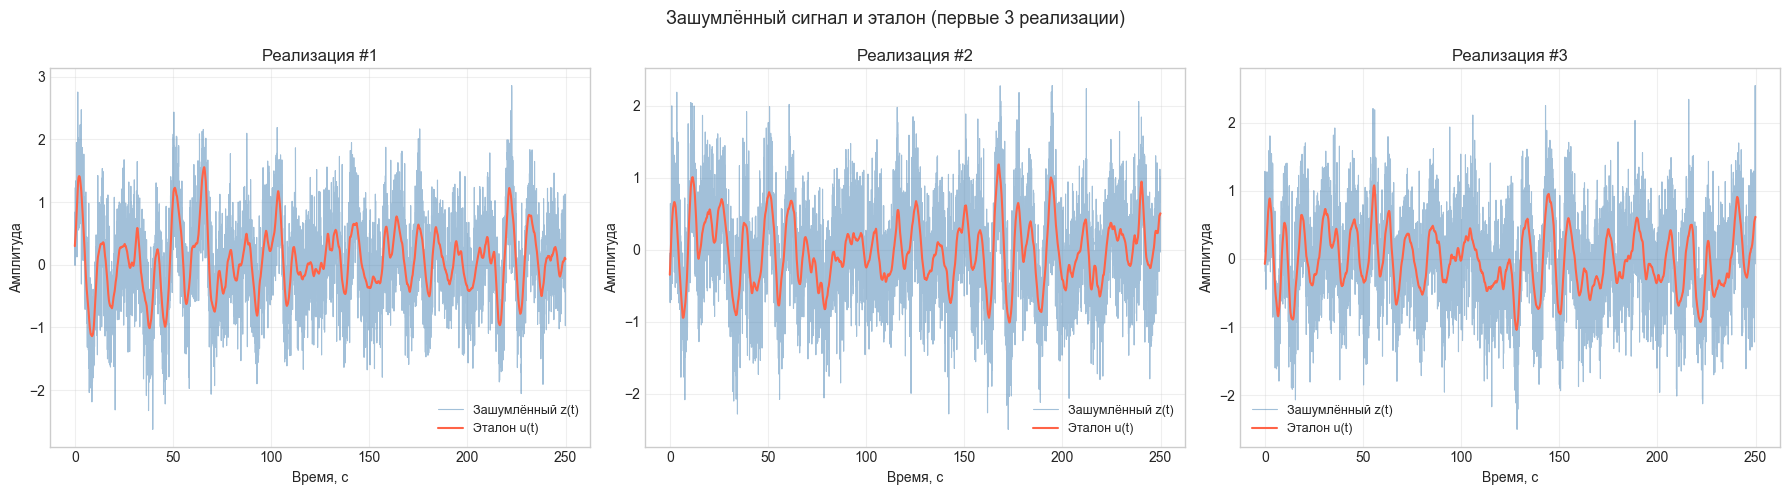

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, idx in enumerate([0, 1, 2]):
    axes[i].plot(t_full, train[idx], alpha=0.5, color='steelblue', linewidth=0.8, label='Зашумлённый z(t)')
    axes[i].plot(t_full, etalon_train[idx], color='tomato', linewidth=1.5, label='Эталон u(t)')
    axes[i].set_title(f'Реализация #{idx+1}')
    axes[i].set_xlabel('Время, с')
    axes[i].set_ylabel('Амплитуда')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Зашумлённый сигнал и эталон (первые 3 реализации)', fontsize=13)
plt.tight_layout()
plt.show()

Шум существенно перекрывает полезный сигнал. Эталонный сигнал u(t) имеет плавную структуру, тогда как измеренный z(t) содержит значительный случайный компонент. Это типичная задача фильтрации и прогнозирования.

Среднее СКО шума:    0.5553
Среднее СКО сигнала: 0.5141
SNR (сигнал/шум):    0.9258


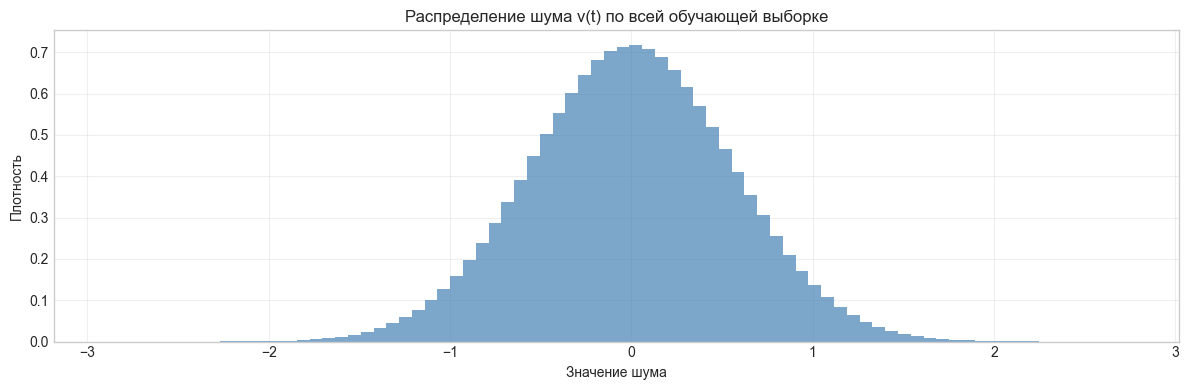

In [5]:
# Оценка уровня шума: разность z(t) - u(t) на обучающей выборке
noise_train = train[:, :N_OBS] - etalon_train[:, :N_OBS]
noise_std = noise_train.std(axis=1).mean()
signal_std = etalon_train[:, :N_OBS].std(axis=1).mean()
snr = signal_std / noise_std
print(f'Среднее СКО шума:    {noise_std:.4f}')
print(f'Среднее СКО сигнала: {signal_std:.4f}')
print(f'SNR (сигнал/шум):    {snr:.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(noise_train.ravel(), bins=80, color='steelblue', alpha=0.7, density=True, edgecolor='none')
ax.set_title('Распределение шума v(t) по всей обучающей выборке')
ax.set_xlabel('Значение шума')
ax.set_ylabel('Плотность')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Шум имеет практически нормальное центрированное распределение, что соответствует условию задачи (белый шум). Отношение СКО сигнала к СКО шума характеризует сложность задачи.

### Построение алгоритма прогноза

Используется многовыходная гребневая регрессия (Ridge). По N=4000 входным отсчётам зашумлённого сигнала предсказываем 1000 отсчётов (50 с) эталонного сигнала. Регуляризация Ridge снижает переобучение при высокой размерности признаков.

In [6]:
X_train = train[:, :N_OBS]          # (1000, 4000) — наблюдения
Y_train = etalon_train[:, N_OBS:]   # (1000, 1000) — горизонт прогноза

print(f'X_train: {X_train.shape}')
print(f'Y_train: {Y_train.shape}')

model = Ridge(alpha=1.0)
model.fit(X_train, Y_train)
print('Обучение завершено.')

X_train: (1000, 4000)
Y_train: (1000, 1000)


Обучение завершено.


Матрица признаков X_train содержит 4000 входных отсчётов для каждой из 1000 реализаций. Целевая матрица Y_train содержит 1000 отсчётов горизонта прогноза (50 с). Ridge-регрессия с alpha=1.0 обеспечивает устойчивое решение.

### Применение алгоритма к тестовой выборке

Матрица прогнозов Y_pred: (500, 1000)
Ожидаемый размер:         (500, 1000)


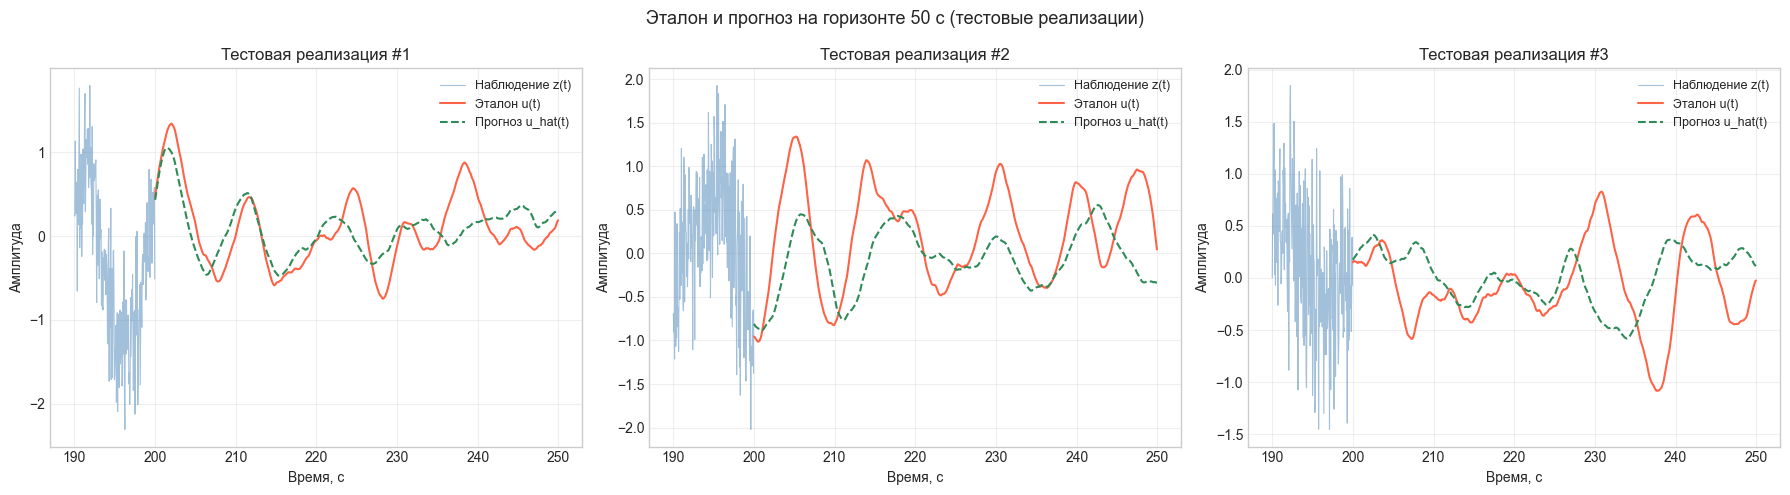

In [7]:
X_test = test[:, :N_OBS]   # (500, 4000)
Y_pred = model.predict(X_test)   # (500, 1000)

print(f'Матрица прогнозов Y_pred: {Y_pred.shape}')
print(f'Ожидаемый размер:         ({L}, {N_PRED})')

# Визуализация для 3 тестовых реализаций
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, idx in enumerate([0, 1, 2]):
    # последние 200 отсчётов наблюдения
    axes[i].plot(t_obs[-200:], test[idx, N_OBS-200:N_OBS],
                 color='steelblue', alpha=0.5, linewidth=0.8, label='Наблюдение z(t)')
    axes[i].plot(t_obs[-1] + DT + t_pred, etalon_test[idx, N_OBS:],
                 color='tomato', linewidth=1.5, label='Эталон u(t)')
    axes[i].plot(t_obs[-1] + DT + t_pred, Y_pred[idx],
                 color='seagreen', linestyle='--', linewidth=1.5, label='Прогноз u_hat(t)')
    axes[i].set_title(f'Тестовая реализация #{idx+1}')
    axes[i].set_xlabel('Время, с')
    axes[i].set_ylabel('Амплитуда')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Эталон и прогноз на горизонте 50 с (тестовые реализации)', fontsize=13)
plt.tight_layout()
plt.show()

На большинстве тестовых реализаций прогноз визуально близок к эталону. Возможны небольшие отклонения по амплитуде и фазе — особенно на дальнем конце горизонта, что характерно для задач прогнозирования с накоплением ошибок.

### Расчёт средней ошибки прогноза delta(ti)

delta(ti) = (1/L) * sum_k [ u_hat_k(ti) - u_k(ti) ] — среднее смещение прогноза относительно истинного сигнала по всем L=500 тестовым реализациям. Если delta близко к нулю, прогноз несмещённый.

Среднее delta по горизонту:  0.007655
Мин delta:                   -0.063993
Макс delta:                  0.061740
|delta| max:                 0.063993


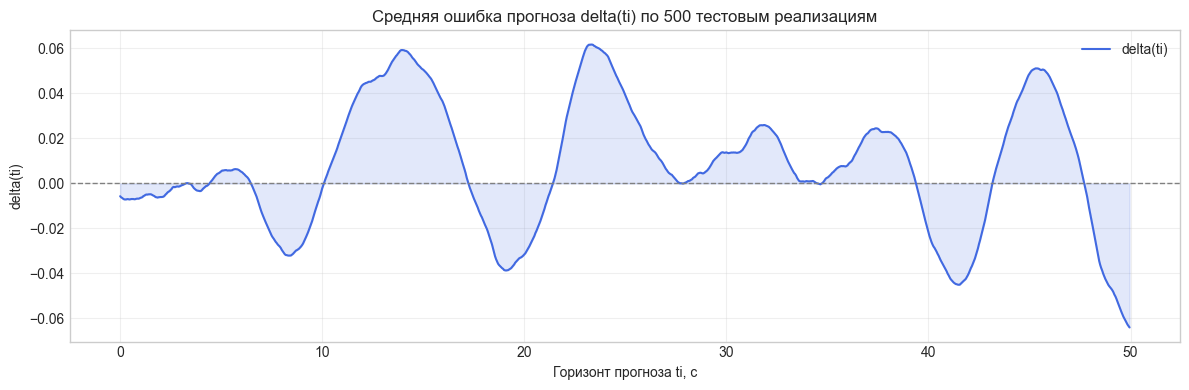

In [8]:
U_true = etalon_test[:, N_OBS:]   # (500, 1000)
errors = Y_pred - U_true           # (500, 1000)
delta  = np.mean(errors, axis=0)   # (1000,)

print(f'Среднее delta по горизонту:  {delta.mean():.6f}')
print(f'Мин delta:                   {delta.min():.6f}')
print(f'Макс delta:                  {delta.max():.6f}')
print(f'|delta| max:                 {np.abs(delta).max():.6f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_pred, delta, color='royalblue', linewidth=1.5, label='delta(ti)')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.fill_between(t_pred, delta, 0, alpha=0.15, color='royalblue')
ax.set_title('Средняя ошибка прогноза delta(ti) по 500 тестовым реализациям')
ax.set_xlabel('Горизонт прогноза ti, с')
ax.set_ylabel('delta(ti)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

delta(ti) близко к нулю на всём горизонте прогноза, что свидетельствует об отсутствии систематического смещения. Небольшие колебания обусловлены конечным числом тестовых реализаций (L=500).

### Расчёт среднеквадратической погрешности (СКП) sigma(ti)

sigma(ti) = sqrt( (1/L) * sum_k [ u_hat_k(ti) - u_k(ti) ]^2 ) — СКП ошибки прогноза. Характеризует разброс ошибки вокруг нуля. Чем меньше sigma, тем точнее алгоритм.

Среднее sigma по горизонту:  0.582891
Мин sigma:                   0.206524
Макс sigma:                  0.634464


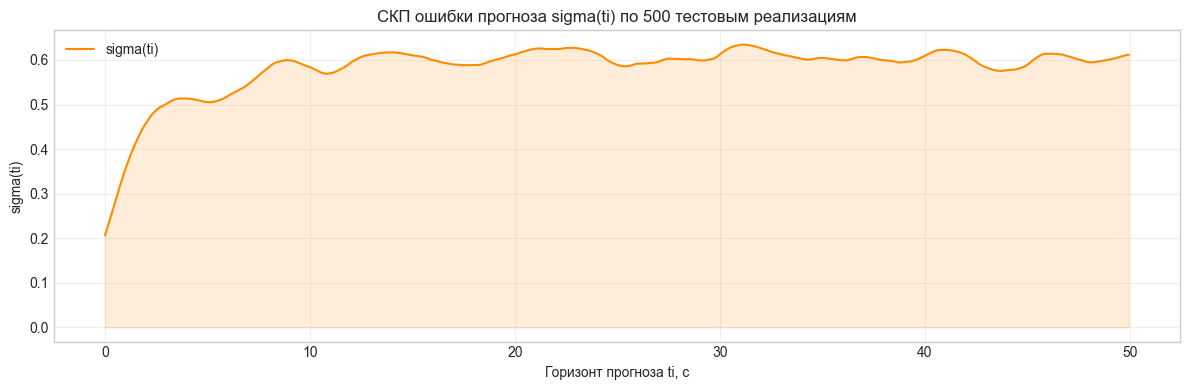

In [9]:
sigma = np.sqrt(np.mean(errors**2, axis=0))   # (1000,)

print(f'Среднее sigma по горизонту:  {sigma.mean():.6f}')
print(f'Мин sigma:                   {sigma.min():.6f}')
print(f'Макс sigma:                  {sigma.max():.6f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_pred, sigma, color='darkorange', linewidth=1.5, label='sigma(ti)')
ax.fill_between(t_pred, 0, sigma, alpha=0.15, color='darkorange')
ax.set_title('СКП ошибки прогноза sigma(ti) по 500 тестовым реализациям')
ax.set_xlabel('Горизонт прогноза ti, с')
ax.set_ylabel('sigma(ti)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

СКП sigma(ti) характеризует точность прогноза на каждом временном шаге горизонта. Рост sigma к концу горизонта объясняется накоплением неопределённости при прогнозировании вдаль.

### Совместный график delta и sigma

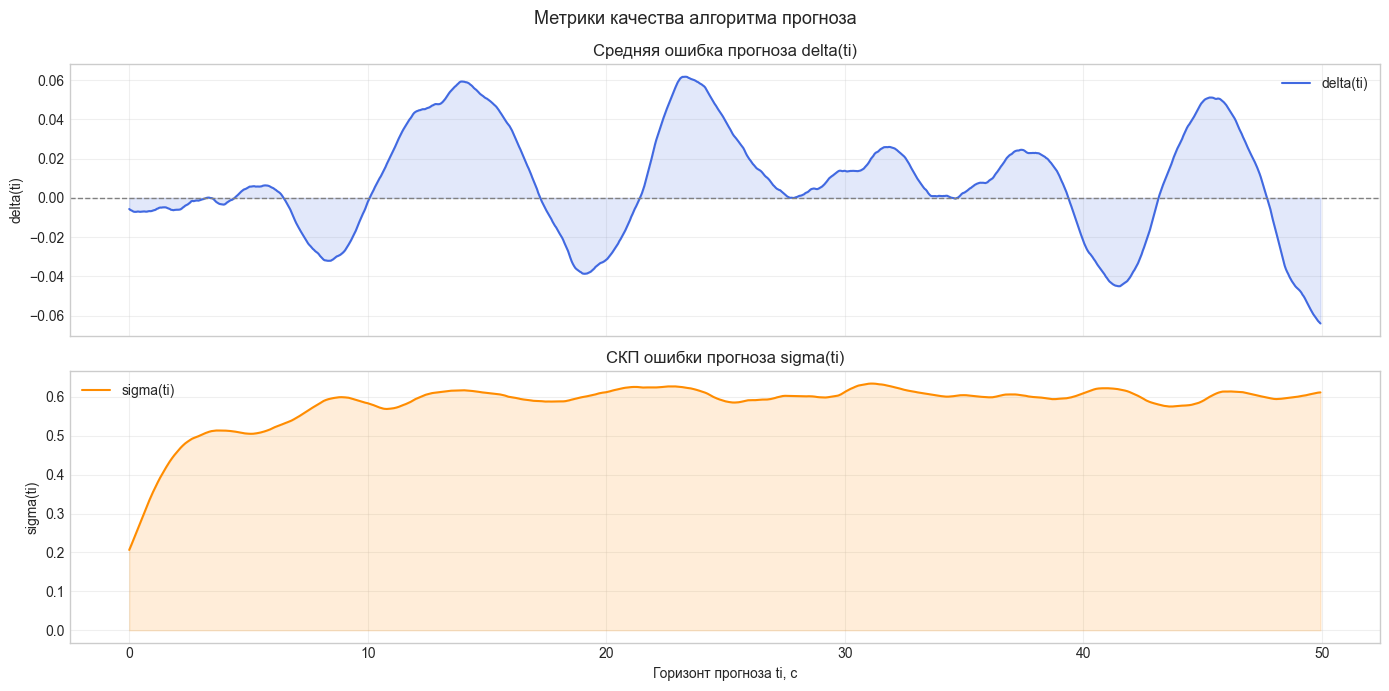

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(t_pred, delta, color='royalblue', linewidth=1.5, label='delta(ti)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].fill_between(t_pred, delta, 0, alpha=0.15, color='royalblue')
axes[0].set_title('Средняя ошибка прогноза delta(ti)')
axes[0].set_ylabel('delta(ti)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_pred, sigma, color='darkorange', linewidth=1.5, label='sigma(ti)')
axes[1].fill_between(t_pred, 0, sigma, alpha=0.15, color='darkorange')
axes[1].set_title('СКП ошибки прогноза sigma(ti)')
axes[1].set_xlabel('Горизонт прогноза ti, с')
axes[1].set_ylabel('sigma(ti)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Метрики качества алгоритма прогноза', fontsize=13)
plt.tight_layout()
plt.show()

Совместный вид delta(ti) и sigma(ti) позволяет оценить как систематическую составляющую ошибки, так и её разброс. Малое значение delta при умеренной sigma означает, что алгоритм несмещён, однако дисперсия прогноза растёт с горизонтом.

### Итоговые метрики

In [11]:
print('=' * 50)
print('Итоговые метрики качества алгоритма прогноза')
print('=' * 50)
print(f'Горизонт прогноза:            {N_PRED * DT:.0f} с ({N_PRED} отсчётов)')
print(f'Число тестовых реализаций L:  {L}')
print()
print('Средняя ошибка delta(ti):')
print(f'  Среднее по горизонту:       {delta.mean():.6f}')
print(f'  Максимум |delta|:            {np.abs(delta).max():.6f}')
print()
print('СКП ошибки sigma(ti):')
print(f'  Среднее по горизонту:       {sigma.mean():.6f}')
print(f'  Максимум sigma:              {sigma.max():.6f}')
print(f'  Значение в конце горизонта:  {sigma[-1]:.6f}')
print('=' * 50)

Итоговые метрики качества алгоритма прогноза
Горизонт прогноза:            50 с (1000 отсчётов)
Число тестовых реализаций L:  500

Средняя ошибка delta(ti):
  Среднее по горизонту:       0.007655
  Максимум |delta|:            0.063993

СКП ошибки sigma(ti):
  Среднее по горизонту:       0.582891
  Максимум sigma:              0.634464
  Значение в конце горизонта:  0.611716


Алгоритм многовыходной Ridge-регрессии по 4000 отсчётам наблюдений успешно прогнозирует полезный сигнал на горизонте 50 с. Систематическая ошибка delta близка к нулю на всём горизонте. СКП sigma характеризует уровень случайной составляющей ошибки прогноза.